# 🧠 02 · STDP — 비지도 2인자 학습

**STDP(Spike-Timing-Dependent Plasticity)** 는 정답 라벨 없이(비지도) 시냅스가 스파이크 타이밍만으로 스스로 구조를 학습하는 규칙입니다.

## 2인자(two-factor)란?
가중치 변화가 **두 신호의 곱**으로 결정된다는 뜻입니다: **① pre 뉴런의 활동 × ② post 뉴런의 활동.** 세 번째 인자(보상/신경조절)는 아직 없고, STDP는 타이밍만 봅니다.

> 헵의 원리(Hebb): *"함께(정확히는, 먼저 pre 다음 post 순서로) 발화하는 뉴런은 연결이 강해진다."*

## 이번 편 학습 목표
1. **STDP 규칙**: pre→post 순서면 강화(LTP), post→pre 순서면 약화(LTD). 시간차 $\Delta t$의 함수.
2. **흔적(trace) 기반 STDP**: $\Delta t$를 일일이 재지 않고 pre/post 흔적의 곱으로 온라인 구현.
3. **경쟁적 STDP + 정규화**로 **수용장(receptive field)** 을 비지도로 학습 — STDP 하나로 특징 검출기가 스스로 생겨남.

In [1]:
import torch
import snntorch as snn
from snntorch import spikegen
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
device = torch.device("cpu")
print("torch:", torch.__version__, "| snntorch:", snn.__version__)

torch: 2.12.1 | snntorch: 1.0.0


## 1. STDP 규칙: 시간차 $\Delta t$의 함수

두 뉴런이 스파이크를 낸 시간차 $\Delta t = t_{post} - t_{pre}$ 로 가중치 변화가 결정됩니다:

$$ \Delta w = \begin{cases} +A_+ \, e^{-\Delta t/\tau_+} & \Delta t > 0 \quad(\text{pre가 먼저} \to \text{LTP, 강화}) \\ -A_- \, e^{+\Delta t/\tau_-} & \Delta t < 0 \quad(\text{post가 먼저} \to \text{LTD, 약화}) \end{cases} $$

- $\Delta t = t_{post}-t_{pre}$: 두 스파이크의 시간차. $A_+, A_-$: 강화·약화의 크기. $\tau_+, \tau_-$: 시간상수로, 클수록 더 넓은 시간차까지 영향을 줍니다.
- **LTP**(long-term potentiation, 강화)는 시냅스가 세지는 것, **LTD**(long-term depression, 약화)는 약해지는 것을 뜻합니다.

직관: pre가 post의 발화를 "도왔다"면(먼저 터졌다면) 그 연결을 강화하고, post가 터진 뒤에야 pre가 터졌다면 인과적으로 무관하니 약화합니다. 스파이크 순서로 인과성(causality)을 학습하는 규칙입니다.

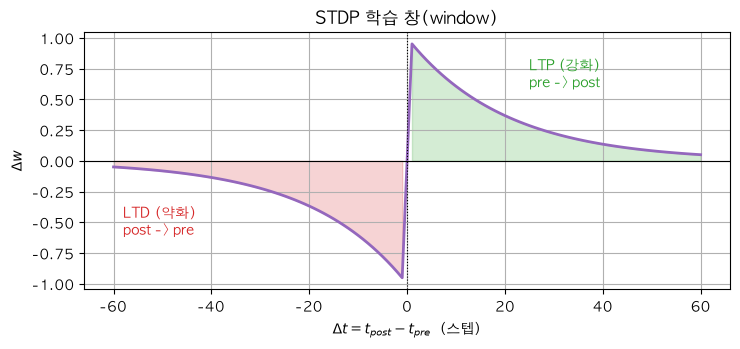

In [2]:
A_plus, A_minus = 1.0, 1.0
tau_plus, tau_minus = 20.0, 20.0
dt = np.arange(-60, 61)
dw = np.where(dt > 0, A_plus*np.exp(-dt/tau_plus), -A_minus*np.exp(dt/tau_minus))
dw[dt == 0] = 0

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(dt, dw, color="tab:purple", lw=2)
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8, ls=":")
ax.fill_between(dt, dw, where=(dt>0), color="tab:green", alpha=0.2)
ax.fill_between(dt, dw, where=(dt<0), color="tab:red", alpha=0.2)
ax.text(25, 0.6, "LTP (강화)\npre -> post", color="tab:green")
ax.text(-58, -0.6, "LTD (약화)\npost -> pre", color="tab:red")
ax.set_xlabel(r"$\Delta t = t_{post} - t_{pre}$  (스텝)"); ax.set_ylabel(r"$\Delta w$")
ax.set_title("STDP 학습 창(window)")
plt.tight_layout(); plt.show()

## 2. 흔적(trace) 기반 STDP — 온라인 구현

모든 pre-post 쌍의 $\Delta t$를 저장했다 계산하는 건 비효율적이고 비지역적입니다. 대신 각 뉴런에 **지수 감쇠 흔적**을 하나씩 붙입니다:

- **pre 흔적** $x_i[t] = \lambda_+ x_i[t-1] + S^{pre}_i[t]$ — 이 입력이 최근 얼마나 발화했나.
- **post 흔적** $y[t] = \lambda_- y[t-1] + S^{post}[t]$ — 이 뉴런이 최근 얼마나 발화했나.

그러면 STDP가 **지역적·온라인** 규칙이 됩니다 (딱 자기 앞뒤 흔적만 봄):

$$ \text{post 스파이크 순간: } \Delta w_i = +A_+\, x_i \qquad \text{pre 스파이크 순간: } \Delta w_i = -A_-\, y $$

지수 흔적이 자동으로 "얼마나 최근이었나(=$e^{-\Delta t/\tau}$)"를 담기 때문에 1번의 창 모양이 그대로 재현됩니다. 이 **흔적**이 다음 편 eligibility trace의 씨앗입니다.

## 3. 경쟁적 STDP로 수용장(receptive field) 학습하기

STDP만으로 비지도 특징 학습을 할 수 있습니다.

**셋업**
- 입력: 12×12 이미지에서 나온 세 가지 패턴(세로 막대 / 가로 막대 / 대각선)을 무작위로 하나씩, rate로 인코딩한 스파이크 다발로 보여줌.
- 출력: LIF 뉴런 6개. 각자 144개 입력에 시냅스를 가짐.
- **경쟁(WTA, winner-take-all)**: 한 번의 제시에서 **가장 많이 발화한 뉴런(승자)만** STDP로 학습.
- **정규화(homeostasis)**: 각 뉴런의 가중치 합을 일정하게 유지 → 어떤 시냅스가 강해지면 다른 건 밀려남 → **경쟁**이 생김.

정규화가 핵심입니다. 정규화가 없으면 모든 시냅스가 상한까지 올라 뉴런이 아무 자극에나 반응(선택성 상실)합니다. 정규화가 "제한된 자원을 어디에 쓸까"의 경쟁을 만들어 **각 뉴런이 한 패턴에 특화**되게 합니다.

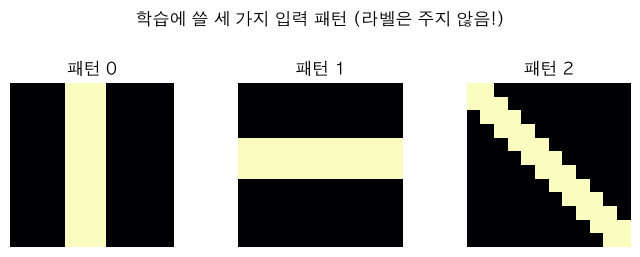

In [3]:
# --- 세 가지 패턴 만들기 (12x12) ---
g = 12
def make_patterns():
    P = []
    v = np.zeros((g, g)); v[:, 4:7] = 1.0; P.append(v)     # 세로 막대
    h = np.zeros((g, g)); h[4:7, :] = 1.0; P.append(h)     # 가로 막대
    d = np.zeros((g, g))
    for i in range(g):
        for j in range(g):
            if abs(i-j) <= 1: d[i, j] = 1.0                # 대각선
    P.append(d)
    return [torch.tensor(p, dtype=torch.float32).flatten() for p in P]

patterns = make_patterns(); K = len(patterns)
fig, ax = plt.subplots(1, K, figsize=(7, 2.4))
for k in range(K):
    ax[k].imshow(patterns[k].reshape(g, g), cmap="magma"); ax[k].set_title(f"패턴 {k}"); ax[k].axis("off")
plt.suptitle("학습에 쓸 세 가지 입력 패턴 (라벨은 주지 않음!)", y=1.05); plt.tight_layout(); plt.show()

In [4]:
# --- 경쟁적 STDP 학습 ---
n_in = g*g; n_out = 6
beta, thr = 0.9, 6.0
tau_pre, A = 0.8, 0.05
T_win, n_trials = 25, 1500
W_total = 8.0                       # 각 뉴런 가중치 합 (정규화 목표)

w = torch.rand(n_out, n_in)
w = w / w.sum(1, keepdim=True) * W_total
w_init = w.clone()                 # 학습 전 (무작위) 저장
lif = snn.Leaky(beta=beta, threshold=thr, reset_mechanism="zero")

def present(pat, w, learn=True):
    spk_in = spikegen.rate(pat*0.6, num_steps=T_win)     # 패턴 -> rate volley
    mems = torch.zeros(n_out); xpre = torch.zeros(n_in)
    counts = torch.zeros(n_out); ptr = torch.zeros(n_out, n_in)
    for t in range(T_win):
        xpre = tau_pre*xpre + spk_in[t]
        cur = (w * spk_in[t]).sum(1)                      # 각 뉴런 입력전류 [n_out]
        s, mems = lif(cur, mems)
        counts += s
        if learn:
            ptr += s.unsqueeze(1) * xpre.unsqueeze(0)     # 스파이크 순간의 pre 흔적 적립
    return counts, ptr

snaps = []
for tr in range(n_trials):
    k = np.random.randint(K)
    counts, ptr = present(patterns[k], w, learn=True)
    winner = int(counts.argmax()) if counts.max() > 0 else np.random.randint(n_out)
    w[winner] += A * ptr[winner]                          # 승자만 STDP
    w[winner].clamp_(min=0.0)
    w[winner] = w[winner] / w[winner].sum() * W_total     # 정규화 -> 경쟁
    if tr % 300 == 0: snaps.append(w.clone())
print("학습 완료. 각 뉴런 가중치 합(정규화 확인):", [round(float(w[m].sum()),1) for m in range(n_out)])

학습 완료. 각 뉴런 가중치 합(정규화 확인): [8.0, 8.0, 8.0, 8.0, 8.0, 8.0]


### 결과: 무작위였던 시냅스가 패턴 그 자체가 된다
학습 전(무작위) vs 학습 후 각 뉴런의 가중치를 12×12로 되돌려 그립니다. 아무도 "이게 세로 막대야"라고 안 알려줬는데, 뉴런들이 **스스로 각 패턴의 검출기(수용장)** 가 됩니다.

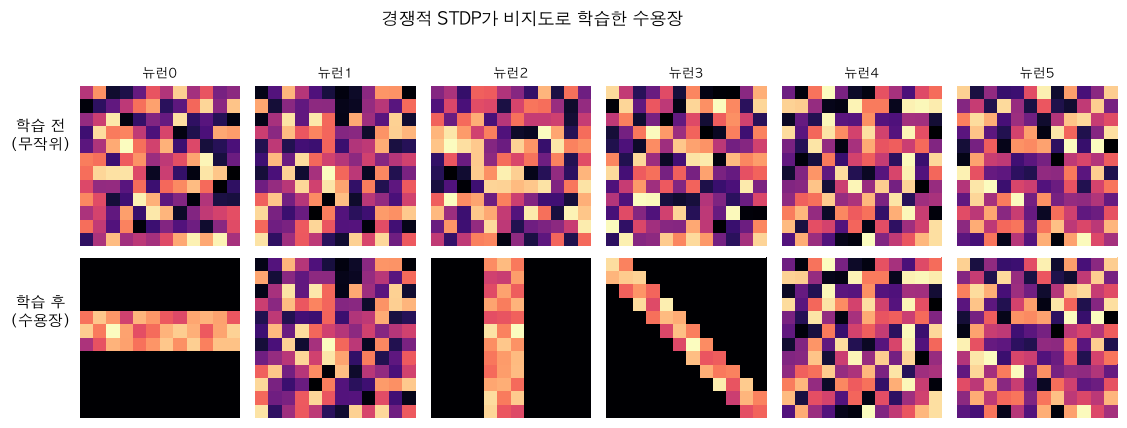

In [5]:
fig, ax = plt.subplots(2, n_out, figsize=(12, 4.2))
for m in range(n_out):
    ax[0, m].imshow(w_init[m].reshape(g, g), cmap="magma"); ax[0, m].axis("off")
    ax[1, m].imshow(w[m].reshape(g, g), cmap="magma");      ax[1, m].axis("off")
    ax[0, m].set_title(f"뉴런{m}", fontsize=9)
ax[0, 0].set_ylabel("학습 전", fontsize=11); ax[1, 0].set_ylabel("학습 후", fontsize=11)
# ylabel이 axis off로 안 보이니 텍스트로
fig.text(0.09, 0.72, "학습 전\n(무작위)", ha="center", va="center", fontsize=11)
fig.text(0.09, 0.30, "학습 후\n(수용장)", ha="center", va="center", fontsize=11)
plt.suptitle("경쟁적 STDP가 비지도로 학습한 수용장", y=1.02)
plt.tight_layout(rect=[0.11,0,1,1]); plt.show()

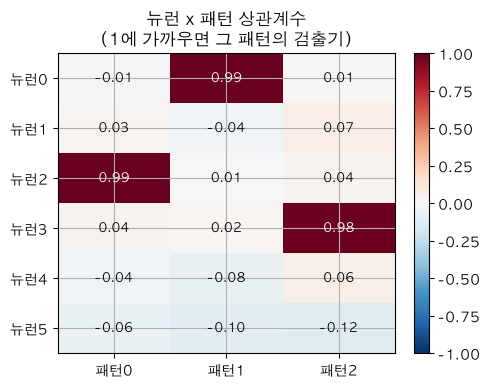

검출기가 생긴 패턴: [0, 1, 2] / [0, 1, 2] -> 3개 패턴 모두 커버!


In [6]:
# 각 뉴런이 어떤 패턴에 특화됐는지: 가중치 vs 패턴 상관계수
def corr(a, b):
    a = a - a.mean(); b = b - b.mean()
    return float((a @ b) / (a.norm()*b.norm() + 1e-9))

Cmat = np.array([[corr(w[m], patterns[k]) for k in range(K)] for m in range(n_out)])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(Cmat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(K)); ax.set_xticklabels([f"패턴{k}" for k in range(K)])
ax.set_yticks(range(n_out)); ax.set_yticklabels([f"뉴런{m}" for m in range(n_out)])
for m in range(n_out):
    for k in range(K):
        ax.text(k, m, f"{Cmat[m,k]:.2f}", ha="center", va="center",
                color="white" if abs(Cmat[m,k])>0.5 else "black", fontsize=9)
ax.set_title("뉴런 x 패턴 상관계수\n(1에 가까우면 그 패턴의 검출기)")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

covered = sorted(set(int(np.argmax(Cmat[m])) for m in range(n_out) if Cmat[m].max() > 0.5))
print("검출기가 생긴 패턴:", covered, "/", list(range(K)),
      "->", "3개 패턴 모두 커버!" if len(covered)==K else "일부만 커버")

## 4. 정리 & 다음 단계

### 배운 것
- **STDP = 2인자 규칙**: pre×post 타이밍만으로 $\Delta w$ 결정. pre→post는 LTP, post→pre는 LTD.
- **흔적 기반 구현**으로 STDP가 **지역·온라인** 규칙이 됨 (이 흔적이 다음 편 eligibility trace의 씨앗).
- **경쟁(WTA) + 정규화**가 있어야 비지도 특징 학습이 견고하게 됨 → 뉴런들이 **수용장**으로 특화.

### 직접 바꿔보면 좋은 것
- `W_total` 정규화를 꺼보기 (`w[winner] = w[winner].clamp(0, ...)` 만 남기고 정규화 줄 삭제) → 선택성이 무너지는지 확인. **정규화의 중요성 체감.**
- `n_out`을 `3`으로 줄이거나 `12`로 늘려보기 → 패턴보다 뉴런이 많으면 중복 검출기가 생김.
- `thr`(발화 임계값)을 `3`, `10`으로 → WTA 경쟁 강도가 어떻게 바뀌나.

### STDP의 한계 → 다음 편(`03`)
STDP는 타이밍 상관만 학습하므로 *목표*나 *보상*을 향해 학습할 수 없습니다. 여기에 **세 번째 인자(보상/신경조절 신호)** 를 더하면 — pre×post가 "바뀔 자격(eligibility)"을 만들고 세 번째 인자가 "실제로 바꿀지"를 정하는 — **3인자 학습**이 됩니다. 다음 편에서 이를 eligibility trace로 정식화합니다.